## Classification Models with Keras

In this lab, we will learn how to use the Keras library to build models for classificaiton problems. We will use the popular MNIST dataset, a dataset of images, for a change. 

The <strong>MNIST database</strong>, short for Modified National Institute of Standards and Technology database, is a large database of handwritten digits that is commonly used for training various image processing systems. The database is also widely used for training and testing in the field of machine learning.
    
The MNIST database contains 60,000 training images and 10,000 testing images of digits written by high school students and employees of the United States Census Bureau.

In [1]:
# Import Libraries
import keras
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Input, Dense, Flatten
from keras.utils import to_categorical
import matplotlib.pyplot as plt

In [2]:
# Load Dataset

(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [3]:
X_train.shape

(60000, 28, 28)

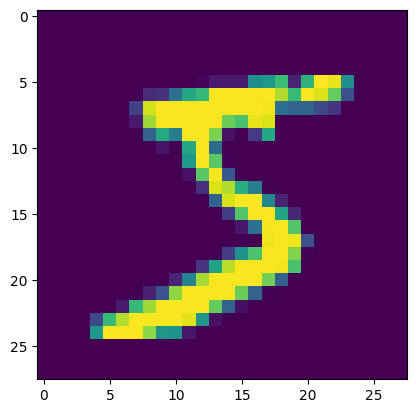

In [4]:
plt.imshow(X_train[0])

### Data Preprocessing

In [5]:
# flatten images into one-dimensional vector

num_pixels = X_train.shape[1] * X_train.shape[2] # find size of one-dimensional vector

X_train = X_train.reshape(X_train.shape[0], num_pixels).astype('float32') # flatten training images
X_test = X_test.reshape(X_test.shape[0], num_pixels).astype('float32') # flatten test images

In [6]:
# normalize inputs from 0-255 to 0-1
X_train = X_train / 255
X_test = X_test / 255

In [7]:
# one hot encode outputs
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

num_classes = y_test.shape[1]
print(num_classes)

10


### Build Neural Network

In [8]:
# define classification model
def classification_model():
    # create model
    model = Sequential()
    model.add(Input(shape=(784,)))
    model.add(Dense(100, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))
    
    
    # compile model
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

### Train and Test the Network

In [13]:
# build the model
model = classification_model()

# fit the model
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=20, verbose=2)

Epoch 1/20
1875/1875 - 6s - 3ms/step - accuracy: 0.9217 - loss: 0.2749 - val_accuracy: 0.9572 - val_loss: 0.1524
Epoch 2/20
1875/1875 - 4s - 2ms/step - accuracy: 0.9618 - loss: 0.1280 - val_accuracy: 0.9674 - val_loss: 0.1093
Epoch 3/20
1875/1875 - 4s - 2ms/step - accuracy: 0.9732 - loss: 0.0888 - val_accuracy: 0.9703 - val_loss: 0.0960
Epoch 4/20
1875/1875 - 4s - 2ms/step - accuracy: 0.9790 - loss: 0.0687 - val_accuracy: 0.9733 - val_loss: 0.0833
Epoch 5/20
1875/1875 - 4s - 2ms/step - accuracy: 0.9834 - loss: 0.0526 - val_accuracy: 0.9742 - val_loss: 0.0847
Epoch 6/20
1875/1875 - 4s - 2ms/step - accuracy: 0.9864 - loss: 0.0429 - val_accuracy: 0.9714 - val_loss: 0.0944
Epoch 7/20
1875/1875 - 5s - 2ms/step - accuracy: 0.9890 - loss: 0.0353 - val_accuracy: 0.9782 - val_loss: 0.0738
Epoch 8/20
1875/1875 - 5s - 2ms/step - accuracy: 0.9913 - loss: 0.0288 - val_accuracy: 0.9783 - val_loss: 0.0739
Epoch 9/20
1875/1875 - 5s - 2ms/step - accuracy: 0.9929 - loss: 0.0243 - val_accuracy: 0.9742 - 

In [14]:
# evaluate the model
scores = model.evaluate(X_test, y_test, verbose=0)
print('Accuracy: {}% \n Error: {}'.format(scores[1], 1 - scores[1]))    

Accuracy: 0.9783999919891357% 
 Error: 0.021600008010864258
